In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
#import nch2369_23 as ns
g = 9.81 # m/s2

#### Parámetros de entrada

In [2]:
T_H = np.linspace(0, 5, 501)
cat = "I"
suelo = "C"
zona_sismica = 2
R = 3
xi = 0.02


#### Clasificación de estructuras y equipos según su importancia.

In [3]:
def coeficiente_importancia(cat="III"):
    cats = { "I": 0.8, "II": 1.0, "III": 1.2, "IV":1.2}
    I = cats[cat]
    return I
I = coeficiente_importancia(cat)

#### Parámetros relativos al tipo de suelo:

In [4]:
def obtener_parametros(suelo):
    parametros_suelo = {
    "A": {"S": 0.90, "r": 4.50, "T_0": 0.15, "p": 1.85, "q": 3.00, "T1": 0.15},
    "B": {"S": 1.00, "r": 4.50, "T_0": 0.30, "p": 1.60, "q": 3.00, "T1": 0.27},
    "C": {"S": 1.05, "r": 4.50, "T_0": 0.40, "p": 1.50, "q": 3.00, "T1": 0.35},
    "D": {"S": 1.00, "r": 3.50, "T_0": 0.60, "p": 1.00, "q": 2.50, "T1": 0.41},
    "E": {"S": 1.00, "r": 3.00, "T_0": 1.20, "p": 1.00, "q": 2.70, "T1": 0.79},
    "F": None  # Indica que se requiere espectro de sitio
}
    if suelo in parametros_suelo:
        return parametros_suelo[suelo]
    else:
        raise ValueError("El tipo de suelo no es válido. Debe ser A, B, C, D o E.")
    
S = obtener_parametros(suelo)["S"]
r = obtener_parametros(suelo)["r"]
T_0 = obtener_parametros(suelo)["T_0"]
p = obtener_parametros(suelo)["p"]
q = obtener_parametros(suelo)["q"]
T1 = obtener_parametros(suelo)["T1"]

#### 5.4. Espectros normativos
$A_0$ $=$ aceleración efectiva máxima del suelo

In [5]:
def aceleracion_efectiva(zona_sismica = 3):
    A0 = {1: 0.2, 2: 0.3, 3: 0.4}
    return A0[zona_sismica]

A_0 = aceleracion_efectiva(zona_sismica)
A_r = 1.4*A_0

#### 5.4.2. Espectro de Referencia
Se define el siguiente espectro de referencia para la dirección horizontal y vertical:

In [6]:
S_aH_TH = np.zeros(len(T_H))
for i in range(len(T_H)):
    S_aH_TH[i] = A_r * S * ((1 + r * (T_H[i] / T_0) ** p) / (1 + (T_H[i] / T_0) ** q))

#### 5.4.1. Espectro de diseño
Se definen los siguientes espectros de diseño para las direcciones horizontal y vertical:

In [7]:
C_r = 0.16 * R
T_s = 1.0
if R == 1: 
    R_star = 1
elif R!= 1 and T_s >= C_r * T_s:
    R_star = R
elif R!= 1 and T_s < C_r * T_s:
    R_star = 1.5+(R+1.5)*T_s/(C_r*T1)

S_a_TH = I * S_aH_TH/R_star * (0.05/xi)**0.4
# S_a_TV = 0.7 * I * S_aV_TV/R * (0.05/xi)**0.4

#### 5.8. Equipos rígidos apoyados en el suelo
El diseñó sísmico de equipos rígidos apoyados en el suelo considera el siguiente factor $K_p$ y aceleración horizontal:

In [8]:
K_p_rig = 1.0
a_k_rig = 1.2 * S * A_0 * I

##### 7.2.2. Equipo no modelado salvo para su masa. Coeficiente sísmico uando no se ha realizado un análisis del edificio:
$C_{p.h}=\frac{a_{k}R_{1}K_{p}}{gR_{p}}$

In [9]:
# C_ph = a_k * R_1 * K_p / (g * R_p)

#### 5.12. Esfuerzo de corte basal mínimo
##### 5.12.1. Coeficiente sísmico mínimo:

In [10]:
C_min = 0.25 *I *A_r *S

#### Coeficiente sísmico máximo:

In [11]:
C_max = ( 2.75 *I *A_r *S ) / ( (R+1) ) * (0.05/xi)**0.4

#### Coeficiente sísmico adoptado:

In [23]:
C_h = max(C_min, min(C_max, max(S_a_TH)))

S_a_TH_plot = np.maximum(np.minimum(S_a_TH, C_h), C_min)

##### Factor de modificación de la respuesta estructural corregido por el requerimiento de corte basal mínimo

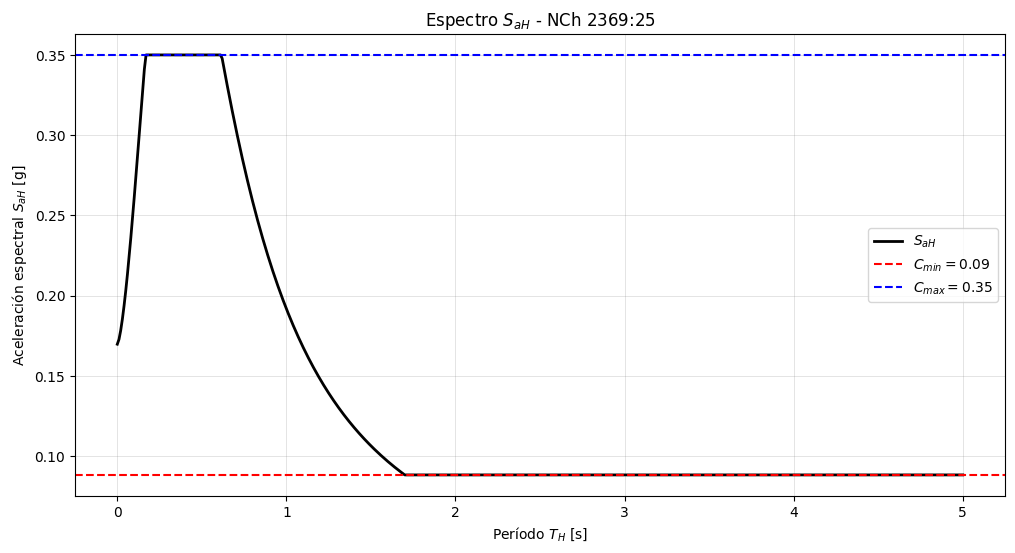

In [27]:
# Encontrar el índice donde se alcanza C_max
idx_max = np.argmax(S_a_TH)
x_max = T_H[idx_max]
y_max = S_a_TH[idx_max]

plt.figure(figsize=(12, 6)) 
plt.plot(T_H, S_a_TH_plot, label=r'$S_{aH}$', color='black', linewidth=2)
plt.axhline(y=C_min, color='r', linestyle='--', label=rf'$C_{{min}} = {C_min:.2f}$')
plt.axhline(y=C_max, color='b', linestyle='--', label=rf'$C_{{max}} = {C_max:.2f}$')
plt.grid(visible=True, which='major', linestyle='-', linewidth=0.5, color='gray', alpha=0.3)

# Anotación de C_max con subíndice
#plt.scatter(x_max, y_max, color='black', zorder=5)
#plt.annotate(rf'$C_{{max}} = {C_max:.2f}$',
#            xy=(x_max, y_max),
#            xytext=(x_max, y_max + 0.1 * C_h),
#            arrowprops=dict(facecolor='red', shrink=0.05),
#            horizontalalignment='center', fontsize=12, color='black')
plt.xlabel(r'Período $T_H$ [s]')
plt.ylabel(r'Aceleración espectral $S_{aH}$ [g]')
plt.title(r'Espectro $S_{aH}$ - NCh 2369:25')

plt.legend()

#### 5.7 Acción Sísmica Vertical
$F_v$ $=$ $C_v P$  
$C_v$ $=$ $1.18 I S A_0/g$

In [14]:
C_v = 1.18 * I * S * A_0
print(f"C_v: {C_v:.2f}")

C_v: 0.30


In [15]:
# Definición de datos técnicos (Ejemplo: Parámetros de Diseño)
data = {
    "Parámetro": ["I", "A_0", "A_r","S","T_0","p","q","r","T_1","C_h","C_v"],
    "Valor":   [I, A_0, A_r, S,T_0,p,q,r,T1,C_h,C_v],
    "Descripción": [f"Coeficiente de importancia Categoría {cat}.", f"Aceleración Efectiva Máxima. Zona Sísmica {zona_sismica}.", "Aceleración máxima de referencia.", f"Parámetro relativo al suelo. Suelo tipo {suelo}.", f"Parámetro relativo al suelo. Suelo tipo {suelo}.", f"Parámetro relativo al suelo. Suelo tipo {suelo}.", f"Parámetro relativo al suelo. Suelo tipo {suelo}.", f"Parámetro relativo al suelo. Suelo tipo {suelo}.", f"Parámetro relativo al suelo. Suelo tipo {suelo}.", "Coeficiente sísmico horizontal.", "Coeficiente sísmico vertical."],
    }

# Creación del DataFrame
df = pd.DataFrame(data)
df_styled = df.style.hide(axis="index").format({"Valor": "{:.2f}"}).set_caption("Parámetros de Diseño Sísmico según NCh 2369:23")

# Visualización optimizada para copia directa
display(df_styled)
# Opción para exportar a LaTeX (formato académico/técnico tradicional)
#print(df.to_latex(escape=False))

Parámetro,Valor,Descripción
I,0.80,Coeficiente de importancia Categoría I.
A_0,0.30,Aceleración Efectiva Máxima. Zona Sísmica 2.
A_r,0.42,Aceleración máxima de referencia.
S,1.05,Parámetro relativo al suelo. Suelo tipo C.
T_0,0.40,Parámetro relativo al suelo. Suelo tipo C.
p,1.50,Parámetro relativo al suelo. Suelo tipo C.
q,3.00,Parámetro relativo al suelo. Suelo tipo C.
r,4.50,Parámetro relativo al suelo. Suelo tipo C.
T_1,0.35,Parámetro relativo al suelo. Suelo tipo C.
C_h,0.35,Coeficiente sísmico horizontal.
